<a href="https://colab.research.google.com/github/Bindiya-Anand/Deep_Learning_Transfer_Learning/blob/main/Notebooks/Phase2_EDA_Bindiya_Anand.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Internmo Data Analytics Project 1
## IndiaKart - E-Com
### Data Analyst Intern: Bindiya Anand
#### Intern Id: Inter563


# Phase 2: Exploratory Data Analysis

In [1]:
# importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# loading cleaned_orders dataset
orders = pd.read_csv('cleaned_orders.csv')
orders.head()

,order_id,customer_id,order_date,order_time,status,city,state,pincode,total_amount,gst_amount,shipping_charge,discount_amount,final_amount,payment_method,shipping_partner,tracking_id,delivered_date,is_cod,channel
0,ORD000001,CUST02946,2025-05-22,17:10:00,Processing,Pune,Maharashtra,300862,100984.19,16364.64,0,20486.45,100984.19,Cash on Delivery,BlueDart,TRK354572763,NaN,1.0,App
1,ORD000002,CUST04232,2023-10-16,05:32:00,Delivered,Ludhiana,Punjab,387852,254478.01,41599.80,0,19338.79,254478.01,UPI,DTDC,TRK272838570,2023-10-19,0.0,Website
2,ORD000003,CUST08078,2023-10-08,12:32:00,Cancelled,Meerut,Uttar Pradesh,294014,32557.06,3562.92,0,696.86,32557.06,Debit Card,Amazon Logistics,TRK338505401,NaN,0.0,App
3,ORD000004,CUST09612,2023-10-02,08:05:00,Delivered,Nashik,Maharashtra,626047,24836.94,3092.88,0,4029.94,24836.94,UPI,DTDC,TRK289792017,2023-10-09,0.0,Mobile Web
4,ORD000005,CUST03065,2024-06-15,20:19:00,Delivered,Moradabad,Uttar Pradesh,409210,156689.29,25092.36,0,7805.07,156689.29,UPI,Ecom Express,TRK978240041,2024-06-22,0.0,App


In [3]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6543 entries, 0 to 6542
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          6543 non-null   object 
 1   customer_id       6543 non-null   object 
 2   order_date        6543 non-null   object 
 3   order_time        6543 non-null   object 
 4   status            6543 non-null   object 
 5   city              6543 non-null   object 
 6   state             6543 non-null   object 
 7   pincode           6543 non-null   int64  
 8   total_amount      6543 non-null   float64
 9   gst_amount        6543 non-null   float64
 10  shipping_charge   6543 non-null   int64  
 11  discount_amount   6543 non-null   float64
 12  final_amount      6543 non-null   float64
 13  payment_method    6543 non-null   object 
 14  shipping_partner  6543 non-null   object 
 15  tracking_id       6543 non-null   object 
 16  delivered_date    4286 non-null   object 


In [6]:
orders['order_date'] = pd.to_datetime(orders['order_date'])
print('Data type of order_date:', orders.order_date.dtype)

Data type of order_date: datetime64[ns]


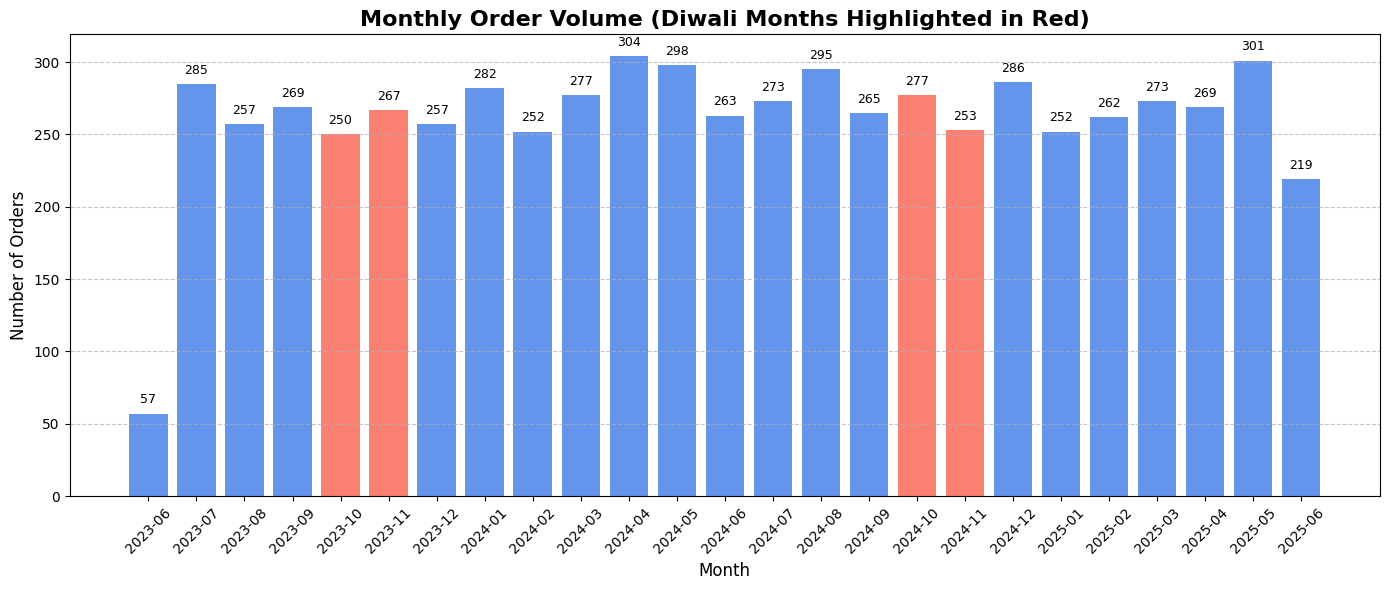

In [16]:
# 1. Monthly order volume — a bar or line chart showing number of orders per month for all 24 months.
# Highlight the Diwali months (Oct, Nov).

# Create a Year-Month column for grouping
orders['year_month'] = orders['order_date'].dt.to_period('M')

# Group and count the orders per month
monthly_orders = orders.groupby('year_month').size().reset_index(name='order_count')
monthly_orders['year_month_str'] = monthly_orders['year_month'].astype(str)
monthly_orders['month_num'] = monthly_orders['year_month'].dt.month

# Plotting
plt.figure(figsize=(14, 6))
colors = ['salmon' if m in [10, 11] else 'cornflowerblue' for m in monthly_orders['month_num']]
#ff9999 #86bfd9
bars = plt.bar(monthly_orders['year_month_str'], monthly_orders['order_count'], color=colors)

# Adding grid and labels
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.title('Monthly Order Volume (Diwali Months Highlighted in Red)', fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)
plt.xticks(rotation=45)

# Add values on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 5, int(yval), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()